# K Means Clustering

### Theory

* Clustering unlabeled data in an unsupervised algorithm
* Attempts to group similar clusters together in your data
* Typical clustering problem looks like:
  * Cluster similar documents
  * Cluster customers based on features
  * Market segmentation
  * Identifying similar physical groups
* Overall goal is to divide data into distinct groups such that observations within each group are similar
<div>
    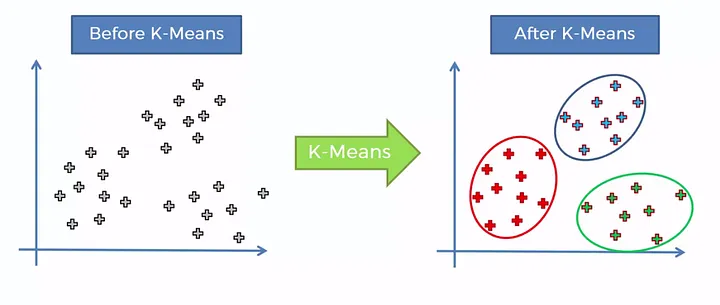
</div> 

* K Means Algorithm
  * Choose a number of clusters "K"
  * Randomly assign each point to a cluster
  * Until clusters stop changing, repeat the following:
    * For each cluster, compute the cluster centroid by taking the mean vector of points in the cluster
    * Assign each data point to the cluster for which the centroid is the closest
  * Process:
    * Data: Start with initial data
    * Step 1: Each observation is <i>randomly</i> assigned to a cluster
    * Iteration 1 (Step 2a): The cluster centroids are then computed. They are usually initially overlapping (because initial cluster assignments were chosen at random)
    * Iteration 1 (Step 2b): Each data point observation is assigned to the nearest centroid
    * Iteration 2 (Step 2a): Lead to new cluster centroids
    * Final Results: (Precursor to final results: Basically keep repeating previous steps until there are no new clusters, and no new data points are being assigned to a new cluster centroid)
* Choosing a K Value
  * No easy answer for choosing best "K" value. No "correct" value either.
  * Best possible route would be computing the Sum of Squared Error (SSE) for some value of K (2, 4, 6, 8, etc.)
  * SSE is defined as the sum of the squared distance between each member of the cluster and it's centroid
  * If we plot K against the SSE, we see that the error decreases as k gets larger. This is because when the number of of clusters increases, the should be smaller, so distortion is also smaller.
  * The idea of the elbow method is to choose the k at which the SSE decreases abruptly.
  * The produces an "elbow effect" in the graph
<div>
    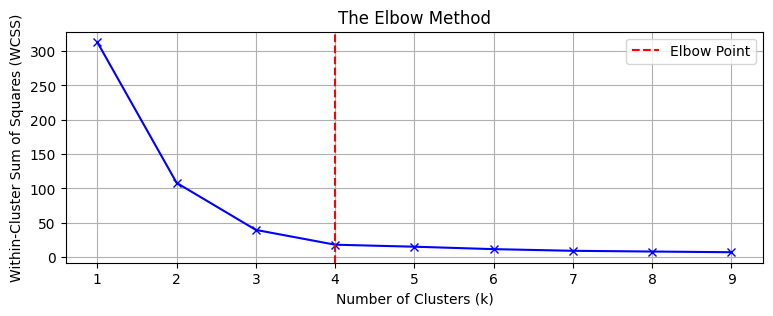
</div>

### Model Building

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Generating artificial data with sci-kit learn
from sklearn.datasets import make_blobs

In [3]:
data = make_blobs(n_samples=200, n_features=2, centers=4, cluster_std=1.8, random_state=101)
data

(array([[-6.42884095e+00,  1.01411174e+01],
        [ 5.86867888e+00,  5.20110356e+00],
        [-3.76109375e-01,  3.26427943e+00],
        [ 2.16679181e+00,  9.56300522e+00],
        [ 5.09508570e+00,  7.20752718e+00],
        [-1.08788882e+01, -6.11318040e+00],
        [ 2.03405554e+00,  9.76664755e+00],
        [-1.71798771e+00,  1.41401140e+00],
        [ 1.16911341e+00,  8.24556988e+00],
        [-1.35185444e+00,  3.13245345e+00],
        [-6.18548214e+00,  9.67406555e+00],
        [-1.19856602e+00,  2.50408937e+00],
        [ 2.90296863e+00,  7.91251003e+00],
        [ 2.39250023e+00,  5.38173971e+00],
        [-5.27545147e+00,  9.63836659e+00],
        [-5.66814687e-01,  5.60262755e-02],
        [ 5.97336628e+00,  5.87172022e+00],
        [-2.31355268e+00,  5.23980092e-01],
        [-1.01344756e+01, -3.43130837e+00],
        [-4.54082629e+00,  1.13920174e+01],
        [-1.04155833e+01, -5.67545836e+00],
        [ 6.64796693e-01,  9.42304718e-02],
        [ 2.11460477e+00,  3.559

In [4]:
#Technically a tuple
data[0].shape

(200, 2)

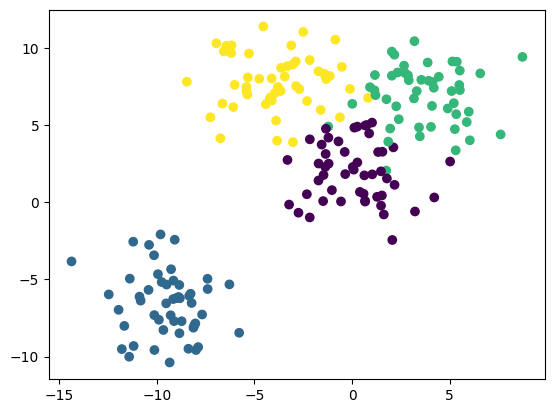

In [5]:
#First object [0] are the features or data points, and the second object [1] is the clusters that the points belong to. (See above)
plt.scatter(data[0][:,0],data[0][:,1], c=data[1])

In [6]:
from sklearn.cluster import KMeans

In [7]:
#Algorithm starts off by randomly assigned each observation to a cluster, and then find the centroid of each cluster
kmeans = KMeans(n_clusters=4)

In [8]:
kmeans.fit(data[0]) #Data features

C:\Users\troyf\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=4)

In [9]:
kmeans.cluster_centers_

array([[-9.46941837, -6.56081545],
       [-4.13591321,  7.95389851],
       [ 3.71749226,  7.01388735],
       [-0.0123077 ,  2.13407664]])

In [10]:
#These are the labels it believes to be true for the clusters
kmeans.labels_

array([1, 2, 3, 2, 2, 0, 2, 3, 2, 3, 1, 3, 2, 2, 1, 3, 2, 3, 0, 1, 0, 3,
       3, 0, 1, 0, 0, 3, 2, 2, 1, 0, 2, 3, 3, 1, 0, 0, 0, 3, 0, 1, 1, 1,
       3, 2, 1, 3, 0, 3, 3, 1, 2, 3, 0, 1, 3, 3, 1, 2, 0, 2, 0, 1, 2, 3,
       0, 2, 2, 0, 2, 3, 0, 3, 0, 2, 2, 3, 1, 3, 3, 0, 2, 0, 3, 3, 3, 1,
       3, 0, 0, 0, 0, 3, 3, 0, 2, 1, 0, 2, 3, 0, 3, 3, 2, 3, 0, 2, 0, 0,
       2, 1, 1, 2, 0, 2, 1, 1, 2, 1, 3, 1, 3, 1, 3, 2, 1, 3, 0, 1, 1, 1,
       3, 0, 0, 1, 2, 1, 2, 3, 0, 2, 0, 1, 1, 2, 3, 0, 1, 1, 1, 1, 3, 2,
       3, 1, 2, 2, 2, 3, 2, 3, 3, 1, 0, 1, 3, 2, 1, 3, 2, 3, 1, 2, 3, 1,
       2, 2, 0, 2, 1, 0, 0, 1, 0, 0, 0, 0, 0, 3, 0, 2, 2, 1, 0, 3, 2, 2,
       0, 3])

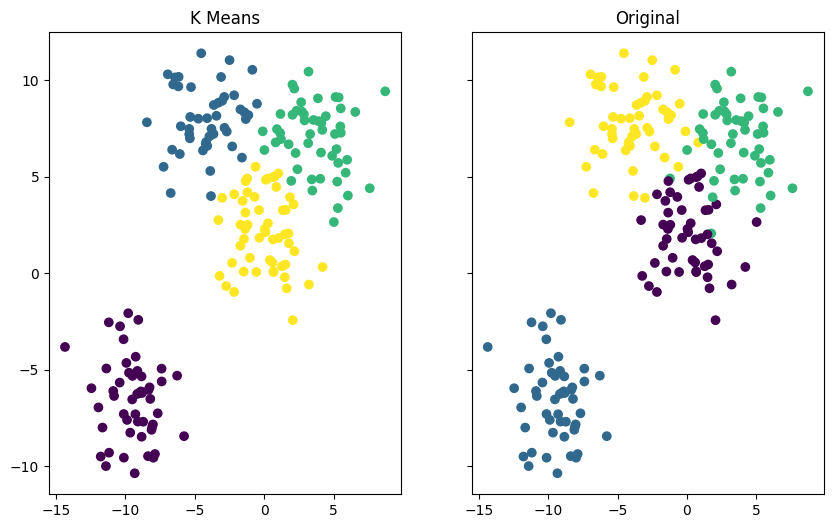

In [11]:
#Comparing KMeans to our original data
fig, (ax1, ax2) = plt.subplots(1,2, sharey=True, figsize=(10,6))

ax1.set_title('K Means')
ax1.scatter(data[0][:,0], data[0][:,1], c=kmeans.labels_)

ax2.set_title('Original')
ax2.scatter(data[0][:,0], data[0][:,1], c=data[1])